In [ ]:
!pip install -q datasets transformers accelerate torchvision timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 53.9 MB/s eta 0:00:00


#Loading and cleaning the dataset

In [ ]:
from datasets import load_dataset
ds = load_dataset("tuankg1028/btc-candlestick-dataset")

ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/269M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/270M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/150M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9417 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1047 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2617 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text', 'label', 'next_close', 'image_path'],
        num_rows: 9417
    })
    validation: Dataset({
        features: ['image', 'text', 'label', 'next_close', 'image_path'],
        num_rows: 1047
    })
    test: Dataset({
        features: ['image', 'text', 'label', 'next_close', 'image_path'],
        num_rows: 2617
    })
})

In [ ]:
sample = ds["train"][0]
sample


{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=893x620>,
 'text': 'Candle: bullish, Price change: 0.54%, Open: 97368.62, High: 97898.81, Low: 97339.16, Close: 97898.80, Volume: normal, Range: 559.65, Body size: 530.18, Upper shadow: 0.01, Lower shadow: 29.46',
 'label': '2',
 'next_close': 97800.0,
 'image_path': 'candle_7870.png'}

In [ ]:
from datasets import load_dataset
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
import torch

ds = load_dataset("tuankg1028/btc-candlestick-dataset")

# label must be INT
def process(batch):
    batch["label"] = int(batch["label"])
    return batch

ds = ds.map(process)

Map:   0%|          | 0/9417 [00:00<?, ? examples/s]

Map:   0%|          | 0/1047 [00:00<?, ? examples/s]

Map:   0%|          | 0/2617 [00:00<?, ? examples/s]

In [ ]:
# Train transform with augmentation to reduce overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Val/test transform — no augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
class CandleDataset(torch.utils.data.Dataset):
    def __init__(self, hf_ds, transform=None):
        self.ds = hf_ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        img = sample["image"]  # PIL Image
        label = int(sample["label"])

        if self.transform:
            img = self.transform(img.convert("RGB"))

        return img, label


In [ ]:
train_set = CandleDataset(ds["train"], train_transform)
val_set   = CandleDataset(ds["validation"], transform)
test_set  = CandleDataset(ds["test"], transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32)
test_loader  = DataLoader(test_set, batch_size=32)

#Training CNN model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CandleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)          # BatchNorm after conv1
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)          # BatchNorm after conv2
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)         # BatchNorm after conv3

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.3)           # Dropout to fight overfitting

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 3)  # 3 classes

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))   # Dropout applied here
        x = self.fc2(x)
        return x

In [ ]:
import numpy as np
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CandleCNN().to(device)

# --- Weighted loss to handle class imbalance ---
label_counts = Counter(int(ds["train"][i]["label"]) for i in range(len(ds["train"])))
total = sum(label_counts.values())
weights = torch.tensor(
    [total / label_counts[c] for c in sorted(label_counts)],
    dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- LR Scheduler: reduce LR when val loss plateaus ---
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

class History:
    def __init__(self):
        self.train_loss = []
        self.train_acc  = []
        self.val_loss   = []   # now tracking val loss too

    def add(self, loss, acc, v_loss=None):
        self.train_loss.append(loss)
        self.train_acc.append(acc)
        if v_loss is not None:
            self.val_loss.append(v_loss)

    def show(self):
        epochs = range(1, len(self.train_loss) + 1)

        plt.figure()
        plt.plot(epochs, self.train_loss, label="Train Loss")
        if self.val_loss:
            plt.plot(epochs, self.val_loss, label="Val Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.title("Loss"); plt.legend(); plt.show()

        plt.figure()
        plt.plot(epochs, self.train_acc)
        plt.xlabel("Epoch"); plt.ylabel("Accuracy")
        plt.title("Training Accuracy"); plt.show()

    def report(self, model, loader, device, target_names=None):
        model.eval()
        preds, labels = [], []

        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x).argmax(dim=1)
                preds.append(out.cpu().numpy())
                labels.append(y.cpu().numpy())

        preds  = np.concatenate(preds)
        labels = np.concatenate(labels)

        acc = accuracy_score(labels, preds)
        print("Accuracy:", acc)
        print(classification_report(labels, preds, target_names=target_names, digits=4))

In [ ]:
!pip install tqdm

In [ ]:
from tqdm.auto import tqdm
import torch

num_epochs = 50          # more epochs — early stopping will cut it if needed
history    = History()

best_val_loss = float("inf")
patience_counter = 0
early_stop_patience = 5  # stop if no improvement for 5 epochs

for epoch in range(num_epochs):
    # ---------- TRAIN ----------
    model.train()
    total_loss = 0
    all_preds  = []
    all_labels = []

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

        progress_bar.set_postfix({"batch_loss": loss.item()})

    avg_loss  = total_loss / len(train_loader)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    train_acc = accuracy_score(all_labels, all_preds)

    # ---------- VALIDATION ----------
    model.eval()
    val_total_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_total_loss += criterion(outputs, labels).item()

    avg_val_loss = val_total_loss / len(val_loader)

    history.add(avg_loss, train_acc, avg_val_loss)

    # Step scheduler based on val loss
    scheduler.step(avg_val_loss)

    # Save best model based on val loss (not train loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "candle_cnn_best.pt")
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1} — Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1/50:   0%|          | 0/295 [00:00<?, ?it/s]

Epoch 1 — Train Loss: 1.2477 | Train Acc: 0.2228 | Val Loss: 1.0612


Epoch 2/50:   0%|          | 0/295 [00:00<?, ?it/s]

Epoch 2 — Train Loss: 0.9949 | Train Acc: 0.4231 | Val Loss: 0.8531


Epoch 3/50:   0%|          | 0/295 [00:00<?, ?it/s]

...

Epoch 19 — Train Loss: 0.5174 | Train Acc: 0.5853 | Val Loss: 0.5314


Epoch 20/50:   0%|          | 0/295 [00:00<?, ?it/s]

Epoch 20 — Train Loss: 0.4964 | Train Acc: 0.5962 | Val Loss: 0.5331


Epoch 21/50:   0%|          | 0/295 [00:00<?, ?it/s]

Epoch 21 — Train Loss: 0.4986 | Train Acc: 0.5899 | Val Loss: 0.4925
Early stopping triggered at epoch 21


In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        all_preds.extend(preds.cpu())
        all_labels.extend(labels.cpu())

acc = accuracy_score(all_labels, all_preds)
print("Validation Accuracy:", acc)


Validation Accuracy: 0.6991404011461319


In [ ]:
def predict(sample):
    img = sample["image"].convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img)
        probs = torch.softmax(out, dim=1)[0]
        pred = torch.argmax(probs).item()

    label_map = {0:"neutral", 1:"bearish", 2:"bullish"}

    return label_map[pred], probs.cpu().numpy()

sample = ds["test"][0]
predict(sample)


('bearish', array([0.00430294, 0.5614937 , 0.43420342], dtype=float32))

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

label_map = {0: "neutral", 1: "bearish", 2: "bullish"}

def predict_and_show(sample):
    model.eval()

    img = sample["image"].convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()
        pred_idx = np.argmax(probs)
        pred_label = label_map[pred_idx]

    # Display image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Prediction: {pred_label}")
    plt.axis("off")
    plt.show()

    print("Predicted Label:", pred_label)
    print("Raw Probabilities:", probs)


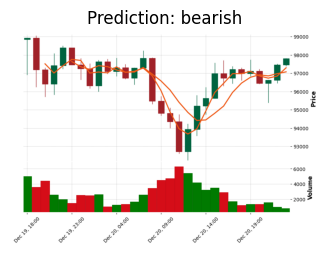

Predicted Label: bearish
Raw Probabilities: [0.00430294 0.5614937  0.43420342]


In [ ]:
sample = ds["test"][0]
predict_and_show(sample)


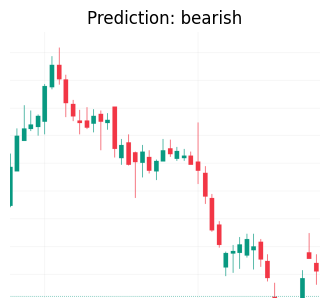

Predicted Label: bearish
Raw Probabilities: [0.03619889 0.8972266  0.0665746 ]


In [ ]:
from PIL import Image

img = Image.open("test.png")

sample = {"image": img}
predict_and_show(sample)

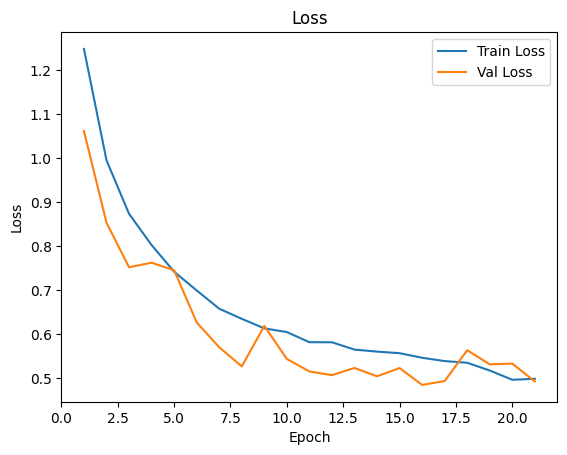

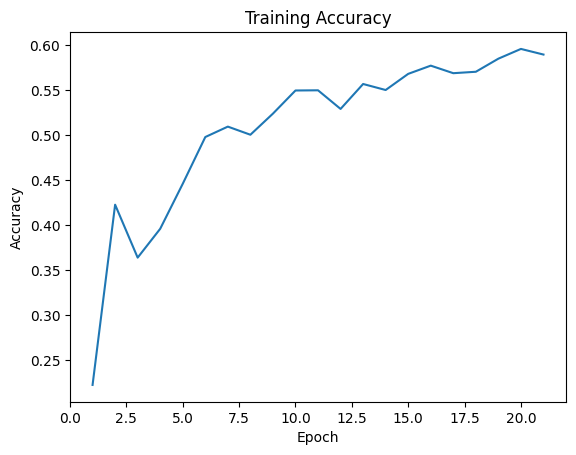

Accuracy: 0.7145586549484142
              precision    recall  f1-score   support

     bearish     0.4722    0.7782    0.5878       284
     neutral     0.9395    0.6776    0.7874      2041
     bullish     0.3929    0.9110    0.5490       292

    accuracy                         0.7146      2617
   macro avg     0.6016    0.7889    0.6414      2617
weighted avg     0.8278    0.7146    0.7391      2617



In [ ]:
# show graphs anytime
history.show()

# classification report + accuracy
history.report(
    model,
    test_loader,
    device=device,
    target_names=["bearish", "neutral", "bullish"]
)


In [ ]:
import torch
from PIL import Image
import torchvision.transforms as transforms

# ---- LOAD (use SAME model variable, don't create a new one) ----
model_path = "candle_cnn_best.pt"   # <-- put your saved file name here

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

print("Model loaded and set to eval()")


Model loaded and set to eval()


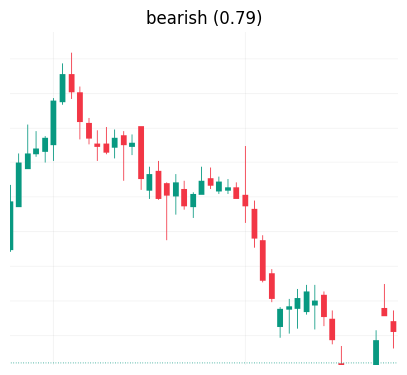


--- Prediction ---
Predicted Index (0=neutral, 1=bearish, 2=bullish): 1
Predicted Label: bearish
Probabilities (neutral, bearish, bullish): [0.1959, 0.7921, 0.012]


('bearish', tensor([[0.1959, 0.7921, 0.0120]]))

In [ ]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt # Import this for plotting

# Assuming 'device', 'model', 'IMG_SIZE', and 'idx_to_name' are defined
# as in your full script and the previous context.

# Setting IMG_SIZE based on the provided PDF where images are resized to 224x224 [cite: 56]
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Resize the image to 224x224 [cite: 56]
    transforms.ToTensor(),
    # The original PDF uses transforms.Normalize(mean=[0.5], std=[0.5]) [cite: 58]
    # We will use the common 3-channel version here for RGB consistency,
    # assuming 'img.convert("RGB")' means 3 channels.
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# --------------------
# LABEL ORDER (0 neutral, 1 bearish, 2 bullish)
# NOTE: This order matches the original mapping {0:"neutral", 1:"bearish", 2:"bullish"}
# for the code in the PDF that resulted in the 'neutral' prediction[cite: 210, 218].
# --------------------
idx_to_name = ["neutral", "bearish", "bullish"] # [cite: 210]

# --------------------
# PREDICTION FUNCTION WITH IMAGE DISPLAY
# --------------------
def predict_on_image(image_path: str):
    # 1. Load and preprocess image
    img = Image.open(image_path).convert("RGB") # Load image [cite: 273]
    x = transform(img).unsqueeze(0).to(device) # Apply transformation and move to device [cite: 273]

    # 2. Model prediction
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1) # Get probabilities [cite: 208]
        pred_idx = int(torch.argmax(probs, dim=1).item()) # Get predicted index [cite: 209]

    # 3. Prepare display and print variables
    pred_label = idx_to_name[pred_idx]
    confidence = probs.squeeze(0).cpu().tolist()[pred_idx]

    # 4. Display image with prediction title
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{pred_label} ({confidence:.2f})") # Title with predicted label and confidence [cite: 268]
    plt.axis("off")
    plt.show()

    # 5. Print results
    print("\n--- Prediction ---")
    print("Predicted Index (0=neutral, 1=bearish, 2=bullish):", pred_idx)
    print("Predicted Label:", pred_label)
    print("Probabilities (neutral, bearish, bullish):",
          [round(p, 4) for p in probs.squeeze(0).cpu().tolist()])

    return pred_label, probs

# --------------------
# TRY IT
# --------------------
predict_on_image("test.png")

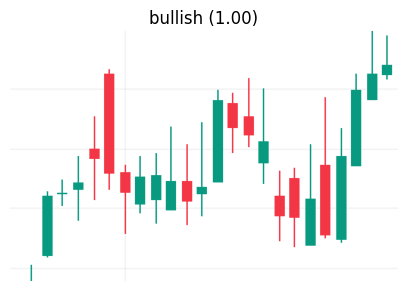


--- Prediction ---
Predicted Index (0=neutral, 1=bearish, 2=bullish): 2
Predicted Label: bullish
Probabilities (neutral, bearish, bullish): [0.0, 0.0026, 0.9974]


('bullish', tensor([[2.1075e-12, 2.5998e-03, 9.9740e-01]]))

In [ ]:
predict_on_image("test1.png")

# ResNet-18 Transfer Learning Model

In [ ]:
from torchvision.models import resnet18
import torch.nn as nn

resnet_model = resnet18(pretrained=True)
resnet_model.fc = nn.Linear(512, 3)  # 3 classes: neutral, bearish, bullish
resnet_model = resnet_model.to(device)

print('ResNet-18 model ready.')
print(f'Total parameters: {sum(p.numel() for p in resnet_model.parameters()):,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 344MB/s]

ResNet-18 model ready.
Total parameters: 11,178,051


In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
import torch
import numpy as np

resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)
resnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer, mode='min', factor=0.5, patience=2
)

resnet_num_epochs = 50
resnet_history = History()
resnet_best_val_loss = float('inf')
resnet_patience_counter = 0
resnet_early_stop_patience = 5

for epoch in range(resnet_num_epochs):
    resnet_model.train()
    total_loss = 0
    all_preds  = []
    all_labels = []

    progress_bar = tqdm(train_loader, desc=f'ResNet Epoch {epoch+1}/{resnet_num_epochs}', leave=True)

    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        resnet_optimizer.zero_grad()
        outputs = resnet_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        resnet_optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
        progress_bar.set_postfix({'batch_loss': loss.item()})

    avg_loss   = total_loss / len(train_loader)
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    train_acc  = accuracy_score(all_labels, all_preds)

    resnet_model.eval()
    val_total_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = resnet_model(imgs)
            val_total_loss += criterion(outputs, labels).item()

    avg_val_loss = val_total_loss / len(val_loader)
    resnet_history.add(avg_loss, train_acc, avg_val_loss)
    resnet_scheduler.step(avg_val_loss)

    if avg_val_loss < resnet_best_val_loss:
        resnet_best_val_loss = avg_val_loss
        resnet_patience_counter = 0
        torch.save(resnet_model.state_dict(), 'resnet_candle_best.pt')
        print(f'  Saved best model (val_loss={avg_val_loss:.4f})')
    else:
        resnet_patience_counter += 1

    print(f'ResNet Epoch {epoch+1} - Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}')

    if resnet_patience_counter >= resnet_early_stop_patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break


ResNet Epoch 1/50:   0%|          | 0/295 [00:00<?, ?it/s]

  Saved best model (val_loss=0.2689)
ResNet Epoch 1 - Train Loss: 0.2925 | Train Acc: 0.8295 | Val Loss: 0.2689


ResNet Epoch 2/50:   0%|          | 0/295 [00:00<?, ?it/s]

ResNet Epoch 2 - Train Loss: 0.2588 | Train Acc: 0.8476 | Val Loss: 0.2824


ResNet Epoch 3/50:   0%|          | 0/295 [00:00<?, ?it/s]

...

ResNet Epoch 14 - Train Loss: 0.0993 | Train Acc: 0.9432 | Val Loss: 0.2661


ResNet Epoch 15/50:   0%|          | 0/295 [00:00<?, ?it/s]

ResNet Epoch 15 - Train Loss: 0.0781 | Train Acc: 0.9570 | Val Loss: 0.3250


ResNet Epoch 16/50:   0%|          | 0/295 [00:00<?, ?it/s]

ResNet Epoch 16 - Train Loss: 0.0729 | Train Acc: 0.9593 | Val Loss: 0.3152
Early stopping triggered at epoch 16


In [ ]:
# Load the best saved ResNet weights
resnet_model.load_state_dict(torch.load('resnet_candle_best.pt', map_location=device))
resnet_model.eval()
print('Best ResNet model loaded and set to eval()')


Best ResNet model loaded and set to eval()


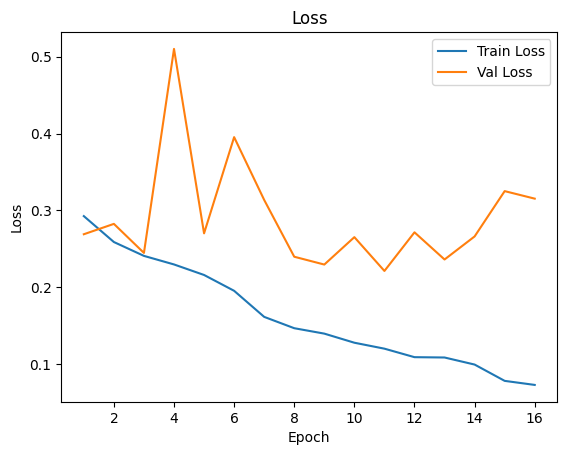

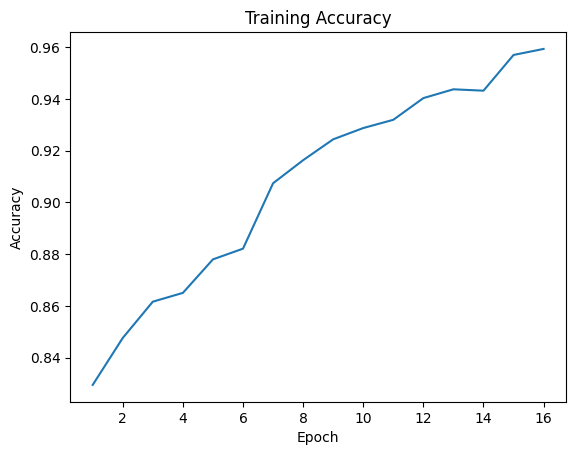

Accuracy: 0.9029423003439052
              precision    recall  f1-score   support

     bearish     0.6658    0.9401    0.7796       284
     neutral     0.9760    0.8976    0.9352      2041
     bullish     0.7788    0.9041    0.8368       292

    accuracy                         0.9029      2617
   macro avg     0.8069    0.9139    0.8505      2617
weighted avg     0.9204    0.9029    0.9073      2617



In [ ]:
# Training curves + full test classification report
resnet_history.show()

resnet_history.report(
    resnet_model,
    test_loader,
    device=device,
    target_names=['bearish', 'neutral', 'bullish']
)


In [ ]:
from sklearn.metrics import accuracy_score

resnet_model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out   = resnet_model(imgs)
        preds = torch.argmax(out, dim=1)
        all_preds.extend(preds.cpu())
        all_labels.extend(labels.cpu())

acc = accuracy_score(all_labels, all_preds)
print('ResNet Validation Accuracy:', acc)


ResNet Validation Accuracy: 0.9035339063992359


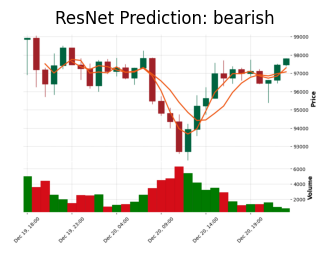

Predicted Label: bearish
Raw Probabilities: [3.5486999e-04 9.9892288e-01 7.2228105e-04]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def resnet_predict_and_show(sample):
    resnet_model.eval()
    img = sample['image'].convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs   = resnet_model(img_tensor)
        probs     = torch.softmax(outputs, dim=1)[0].cpu().numpy()
        pred_idx  = np.argmax(probs)
        pred_label = label_map[pred_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'ResNet Prediction: {pred_label}')
    plt.axis('off')
    plt.show()

    print('Predicted Label:', pred_label)
    print('Raw Probabilities:', probs)

sample = ds['test'][0]
resnet_predict_and_show(sample)


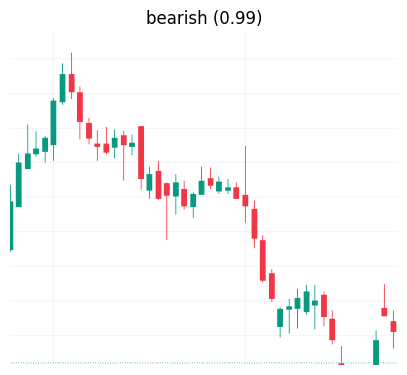


--- ResNet Prediction ---
Predicted Index (0=neutral, 1=bearish, 2=bullish): 1
Predicted Label: bearish
Probabilities (neutral, bearish, bullish): [0.0012, 0.9947, 0.0042]


('bearish', tensor([[0.0012, 0.9947, 0.0042]]))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def resnet_predict_on_image(image_path: str):
    img = Image.open(image_path).convert('RGB')
    x   = transform(img).unsqueeze(0).to(device)

    resnet_model.eval()
    with torch.no_grad():
        logits     = resnet_model(x)
        probs      = torch.softmax(logits, dim=1)
        pred_idx   = int(torch.argmax(probs, dim=1).item())

    pred_label = idx_to_name[pred_idx]
    confidence = probs.squeeze(0).cpu().tolist()[pred_idx]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'{pred_label} ({confidence:.2f})')
    plt.axis('off')
    plt.show()

    print('\n--- ResNet Prediction ---')
    print('Predicted Index (0=neutral, 1=bearish, 2=bullish):', pred_idx)
    print('Predicted Label:', pred_label)
    print('Probabilities (neutral, bearish, bullish):',
          [round(p, 4) for p in probs.squeeze(0).cpu().tolist()])

    return pred_label, probs

resnet_predict_on_image('test.png')
